<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/session10-cnns-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Session 10 — CNNs in code {.unnumbered}

Three parts, following the book page:

1. **Convolution and images.** Why weight sharing gives translation
   equivariance, then **colorectal cancer histology** (nine tissue types,
   only 40 labelled training tiles each): a small CNN from scratch, the
   same CNN with data augmentation, and transfer learning from two
   pretrained networks, an ImageNet-trained ResNet-18 and the
   self-supervised foundation model DINOv2. Plus a test of what a CNN is
   *not* invariant to: rotation.
2. **CNNs on protein sequences.** Sessions 8-9's subcellular-localization
   dataset and homology-aware split, now with a 1D CNN, and a look inside
   its first layer: the filters behave like learned PWMs (Session 5).
3. **Contact maps.** A real contact map computed from hemoglobin's 3D
   structure (Session 6): the kind of 2D image that deep CNNs learned to
   predict from sequence alignments between 2016 and 2018.

**Runtime.** Part 1 trains the small CNN six times (three random seeds,
without and with augmentation) for `EPOCHS = 100` epochs. On a GPU (Colab:
*Runtime → Change runtime type → T4 GPU*) that takes about 5 minutes in
total. On a CPU, set `EPOCHS = 30` for a quicker, lower-accuracy run.

In [1]:
# Install the libraries Colab does not come with (does nothing if they are already installed)
import importlib.util, subprocess, sys
for module, package in [("Bio", "biopython"), ("transformers", "transformers")]:
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)
import io, os, tempfile, urllib.request
import torchvision
from torchvision import transforms as T
from torch.utils.data import DataLoader, Dataset, TensorDataset
from PIL import Image
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = False          # reproducible GPU training
torch.backends.cudnn.deterministic = True
FIGS = "../figs" if os.path.isdir("../figs") else "."
print("device:", device)

device: cuda


# Part 1 — Convolution and images

## Part 1: why convolution gives translation equivariance (and, with pooling, invariance)

A 1D convolution slides the *same* small kernel across every position of its
input. If the input signal is shifted, the kernel sees the same local pattern,
just later (or earlier) -- so the output feature map should shift by exactly
the same amount. That is **equivariance**: `conv(shift(x)) == shift(conv(x))`
(up to the boundary, where the kernel runs off the edge). This is a property
of the architecture itself -- weight sharing -- and holds even for a
completely untrained, randomly-initialized kernel, which is what we use below
so there is no training involved in this demonstration at all.

In [3]:
conv = nn.Conv1d(in_channels=1, out_channels=1, kernel_size=5, padding=2, bias=False)

# A toy signal: a single sharp "bump" at position 20 in a length-60 sequence.
length = 60
signal = torch.zeros(1, 1, length)
signal[0, 0, 20] = 1.0

shift = 10
shifted_signal = torch.zeros(1, 1, length)
shifted_signal[0, 0, 20 + shift] = 1.0

with torch.no_grad():
    out = conv(signal)[0, 0].numpy()
    out_shifted = conv(shifted_signal)[0, 0].numpy()

# Compare: shifting the OUTPUT of the original by `shift` positions should
# match the output computed from the ALREADY-shifted input (away from the
# boundary effects near the edges where the kernel runs off the sequence).
out_rolled = np.roll(out, shift)
interior = slice(10, 50)  # stay away from both edges
max_abs_diff = np.max(np.abs(out_rolled[interior] - out_shifted[interior]))
print(f"max |shift(conv(x)) - conv(shift(x))| over the interior region: {max_abs_diff:.2e}")
print("equivariant (matches to floating-point precision away from the edges):", max_abs_diff < 1e-6)

max |shift(conv(x)) - conv(shift(x))| over the interior region: 0.00e+00
equivariant (matches to floating-point precision away from the edges): True


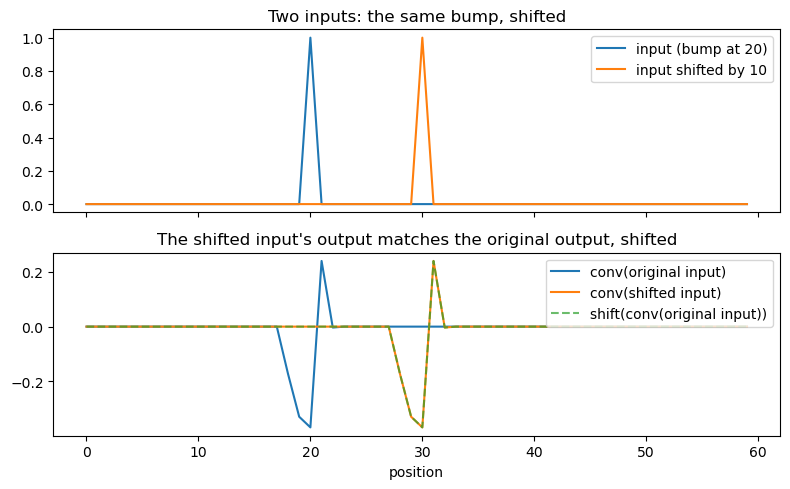

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(signal[0, 0].numpy(), label="input (bump at 20)")
axes[0].plot(shifted_signal[0, 0].numpy(), label=f"input shifted by {shift}")
axes[0].set_title("Two inputs: the same bump, shifted")
axes[0].legend()
axes[1].plot(out, label="conv(original input)")
axes[1].plot(out_shifted, label="conv(shifted input)")
axes[1].plot(out_rolled, "--", label="shift(conv(original input))", alpha=0.7)
axes[1].set_title("The shifted input's output matches the original output, shifted")
axes[1].legend()
axes[1].set_xlabel("position")
plt.tight_layout()
plt.savefig("../figs/session10-conv-equivariance.png", dpi=150)
plt.show()

**From equivariance to invariance.** Equivariance alone still leaves the bump
at a different position in the output feature map -- useful, but not yet
"the same answer regardless of position." **Global pooling** (taking the
max, or the mean, over the whole feature map) removes the position
information entirely: the *value* of the peak is preserved by shifting, so
its max is too, regardless of where it sits. That combination --
weight-shared convolution (equivariant) followed by global pooling
(position-independent) -- is what gives a convolutional network
translation invariance, and it requires no training to exist as a structural
property of the architecture.

In [5]:
pooled_original = out.max()
pooled_shifted = out_shifted.max()
print(f"max-pooled output, original input:  {pooled_original:.6f}")
print(f"max-pooled output, shifted input:   {pooled_shifted:.6f}")
print("identical after pooling:", np.isclose(pooled_original, pooled_shifted))

max-pooled output, original input:  0.239905
max-pooled output, shifted input:   0.239905
identical after pooling: True


## Colorectal cancer histology: very little labelled data

A pathologist looks at thin slices of tissue stained with haematoxylin
(nuclei, purple) and eosin (cytoplasm and connective tissue, pink). Kather
and colleagues cut such H&E slides of colorectal cancer into small square
tiles of 224 × 224 pixels (0.5 µm per pixel, so each tile is 112 µm
across) and labelled each tile with one of **nine tissue types**
(NCT-CRC-HE-100K; Kather et al. 2019, *PLoS Med* 16:e1002730; CC BY 4.0).

The full data set has 100,000 tiles from 86 slides, plus 7,180 tiles from
50 *other* patients (CRC-VAL-HE-7K). Labelled medical images are expensive,
so we pretend we only have **40 labelled tiles per class**:

- **training**: 40 tiles per class from the large set;
- **validation**: 40 other tiles per class from the large set. They can
  come from the same slides as the training tiles;
- **test**: 100 tiles per class from the 50 other patients.

The subset (9.5 MB, tiles shrunk to 112 × 112 pixels) is hosted with this
notebook; `make_crc_subset.py` in the course repository shows how it was
cut from the original files.

train   360 tiles, per class 40-40
val     360 tiles, per class 40-40
test    900 tiles, per class 100-100


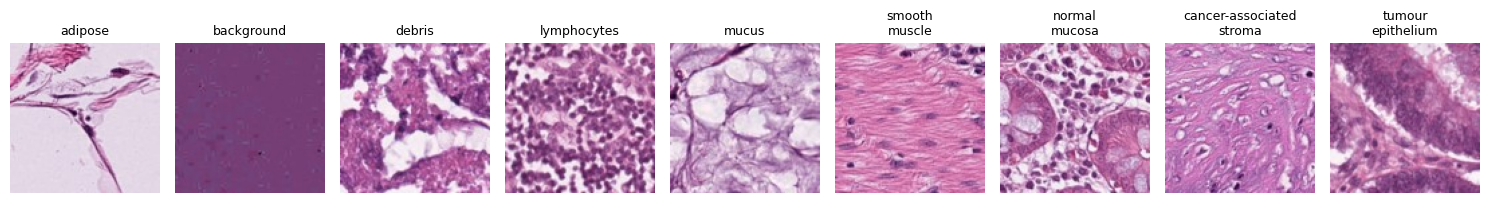

In [6]:
EPOCHS = 100          # 30 is fine for a quick CPU run (lower accuracy)
USE_FULL_TEST = False # True: test on all 7,180 tiles of the 50 held-out patients (800 MB download)

SUBSET_URL = "https://raw.githubusercontent.com/ElofssonLab/kb8029-book/main/notebooks/data/crc-histology-subset.npz"
FULL_TEST_URL = "https://zenodo.org/records/1214456/files/CRC-VAL-HE-7K.zip?download=1"

def download(url, filename):
    """Download url into the temporary directory once, and return the local path."""
    path = os.path.join(tempfile.gettempdir(), filename)
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path + ".part")
        os.replace(path + ".part", path)
    return path

local = "data/crc-histology-subset.npz"
d = np.load(local if os.path.exists(local) else download(SUBSET_URL, "crc-histology-subset.npz"))
CODES, CLASS_NAMES = list(d["class_codes"]), list(d["class_names"])

def decode(split):
    """The JPEG-compressed tiles of one split as a list of PIL images, and their labels."""
    jpeg, off = d[f"{split}_jpeg"], d[f"{split}_offsets"]
    images = [Image.open(io.BytesIO(jpeg[off[i]:off[i + 1]].tobytes())).convert("RGB") for i in range(len(off) - 1)]
    return images, d[f"{split}_labels"]

tiles = {split: decode(split) for split in ["train", "val", "test"]}
if USE_FULL_TEST:
    import zipfile
    zf = zipfile.ZipFile(download(FULL_TEST_URL, "CRC-VAL-HE-7K.zip"))
    names = [n for n in zf.namelist() if n.endswith(".tif")]
    tiles["test"] = ([Image.open(zf.open(n)).convert("RGB").resize((112, 112), Image.BILINEAR) for n in names],
                     np.array([CODES.index(n.split("/")[-2]) for n in names]))
for split, (images, labels) in tiles.items():
    print(f"{split:5s} {len(images):5d} tiles, per class {np.bincount(labels).min()}-{np.bincount(labels).max()}")

fig, axes = plt.subplots(1, 9, figsize=(15, 2.3))
for k, ax in enumerate(axes):
    ax.imshow(tiles["train"][0][int(np.where(tiles["train"][1] == k)[0][0])])
    ax.set_title(CLASS_NAMES[k].replace(" ", "\n", 1), fontsize=9); ax.axis("off")
plt.tight_layout(); plt.savefig(f"{FIGS}/session10-crc-classes.png", dpi=150, bbox_inches="tight"); plt.show()

**Data augmentation** creates a new, slightly changed version of every
training image in every epoch, with the same label. It tells the network
which changes should *not* matter. For tissue the choice is easy: a
section has no "up" and no "left", so every rotation by 90° and every
mirror image is an equally valid tile. We add a mild random zoom, and
small changes of brightness and colour, because the strength of the stain
varies from lab to lab.

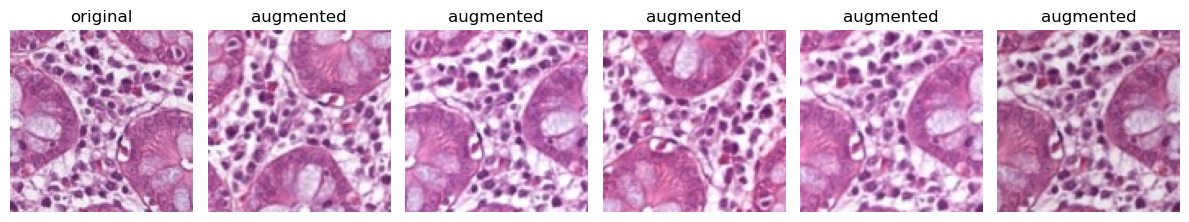

In [7]:
class RotateFlip:
    """One of the eight symmetries of a square: rotate by 0, 90, 180 or 270 degrees, maybe mirror."""
    def __call__(self, img):
        img = img.rotate(90 * np.random.randint(4))
        return img.transpose(Image.FLIP_LEFT_RIGHT) if np.random.rand() < 0.5 else img

norm = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])     # ImageNet channel statistics
plain_tf = T.Compose([T.ToTensor(), norm])
augment = T.Compose([RotateFlip(), T.RandomResizedCrop(112, scale=(0.8, 1.0), ratio=(1, 1)),
                     T.ColorJitter(0.1, 0.1, 0.1, 0.02)])
aug_tf = T.Compose([augment, T.ToTensor(), norm])

class Tiles(Dataset):
    def __init__(self, split, tf):
        self.images, self.labels = tiles[split]; self.tf = tf
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.tf(self.images[i]), int(self.labels[i])

def cache(ds):
    """Transform every image once and keep the tensors in memory (for data without random augmentation)."""
    xs, ys = zip(*[ds[i] for i in range(len(ds))])
    return TensorDataset(torch.stack(xs), torch.tensor(ys))
train_plain_c, val_c, test_c = cache(Tiles("train", plain_tf)), cache(Tiles("val", plain_tf)), cache(Tiles("test", plain_tf))
train_aug = Tiles("train", aug_tf)

np.random.seed(1); torch.manual_seed(1)
img0 = tiles["train"][0][int(np.where(tiles["train"][1] == 6)[0][0])]     # a normal-mucosa tile
fig, axes = plt.subplots(1, 6, figsize=(12, 2.4))
axes[0].imshow(img0); axes[0].set_title("original")
for ax in axes[1:]:
    ax.imshow(augment(img0)); ax.set_title("augmented")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.savefig(f"{FIGS}/session10-augmentation.png", dpi=150, bbox_inches="tight"); plt.show()

### A small CNN, trained from scratch

Four blocks of convolution (3×3) → batch normalization → ReLU → 2×2 max
pooling, then global average pooling and a linear layer to the nine
classes. It has about 250,000 weights, and we have 360 training tiles. We
train it without and with augmentation, each with three different random
seeds: with so few examples, the result of a single run is partly luck.

In [8]:
def small_cnn(n_classes=9):
    block = lambda i, o: [nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(), nn.MaxPool2d(2)]
    return nn.Sequential(*block(3, 32), *block(32, 64), *block(64, 128), *block(128, 128),
                         nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n_classes))

def predict(model, dataset):
    model.eval(); out = []
    with torch.no_grad():
        for x, _ in DataLoader(dataset, batch_size=256):
            out.append(model(x.to(device)).argmax(1).cpu())
    return torch.cat(out).numpy()

def evaluate(model, dataset):
    return (predict(model, dataset) == dataset.tensors[1].numpy()).mean()          # cached datasets only

def train_cnn(train_set, epochs=EPOCHS, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    model = small_cnn().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loader = DataLoader(train_set, batch_size=32, shuffle=True, generator=torch.Generator().manual_seed(seed))
    hist, best = [], (0.0, None)
    for epoch in range(epochs):
        model.train()
        for x, y in loader:
            opt.zero_grad()
            nn.functional.cross_entropy(model(x.to(device)), y.to(device)).backward()
            opt.step()
        tr, va = evaluate(model, train_plain_c), evaluate(model, val_c)
        hist.append((tr, va))
        if va > best[0]:
            best = (va, {k: v.clone() for k, v in model.state_dict().items()})
    model.load_state_dict(best[1])                      # early stopping on validation accuracy
    return model, hist

results, models = {}, {}
for name, ds in [("from scratch", train_plain_c), ("from scratch + augmentation", train_aug)]:
    runs = []
    for seed in range(3):
        model, hist = train_cnn(ds, seed=seed)
        best_ep = int(np.argmax([v for _, v in hist]))
        runs.append(dict(hist=hist, val=hist[best_ep][1], train=hist[best_ep][0], test=evaluate(model, test_c)))
        if seed == 0:
            models[name] = model
        print(f"{name:28s} seed {seed}: best val {runs[-1]['val']:.3f} (epoch {best_ep + 1}), "
              f"train acc then {runs[-1]['train']:.3f}  ->  TEST {runs[-1]['test']:.3f}")
    results[name] = dict(runs=runs, val=np.mean([r["val"] for r in runs]), test=np.mean([r["test"] for r in runs]),
                         test_range=(min(r["test"] for r in runs), max(r["test"] for r in runs)))
print(f"\nweights in the small CNN: {sum(p.numel() for p in models['from scratch'].parameters()):,}")

from scratch                 seed 0: best val 0.869 (epoch 99), train acc then 1.000  ->  TEST 0.786


from scratch                 seed 1: best val 0.867 (epoch 99), train acc then 0.983  ->  TEST 0.721


from scratch                 seed 2: best val 0.847 (epoch 84), train acc then 0.992  ->  TEST 0.729


from scratch + augmentation  seed 0: best val 0.850 (epoch 74), train acc then 0.894  ->  TEST 0.769


from scratch + augmentation  seed 1: best val 0.858 (epoch 81), train acc then 0.928  ->  TEST 0.821


from scratch + augmentation  seed 2: best val 0.856 (epoch 91), train acc then 0.906  ->  TEST 0.787

weights in the small CNN: 242,697


### Transfer learning: borrow features learned on millions of images

The alternative that took over the field: start from a network that has
already learned general visual features, keep it **frozen**, and train
only a new last layer (here a logistic regression) on our 360 tiles. We
try two such networks:

- **ResNet-18** (He et al., 2016), trained with labels on 1.2 million
  ImageNet photos (cats, cars, mushrooms; no tissue). Each tile becomes
  512 numbers.
- **DINOv2** (Oquab et al., 2023), a small vision Transformer (ViT-S/14,
  22 million weights) trained *without any labels* on 142 million images:
  it learned by making its description of a picture agree with its
  description of other, cropped and distorted versions of the same
  picture. This is a **foundation model**: trained once, at great cost,
  on huge unlabelled data, then reused for many tasks. Each tile becomes
  384 numbers.

Both expect 224 × 224 pixel inputs, so the tiles are enlarged.

In [9]:
import warnings
warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"       # quiet downloads (set before importing transformers)
os.environ["HF_HUB_VERBOSITY"] = "error"
from sklearn.linear_model import LogisticRegression
from transformers import AutoModel
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()

resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1).to(device).eval()
resnet_backbone = nn.Sequential(*list(resnet.children())[:-1], nn.Flatten())   # everything except the last layer
dinov2 = AutoModel.from_pretrained("facebook/dinov2-small").to(device).eval()
backbones = {"transfer: ResNet-18 (ImageNet)": resnet_backbone,
             "transfer: DINOv2 (self-supervised)": lambda x: dinov2(pixel_values=x).pooler_output}
tf224 = T.Compose([T.Resize(224), T.ToTensor(), norm])

def features(backbone, split, tf=tf224):
    out = []
    with torch.no_grad():
        for x, _ in DataLoader(Tiles(split, tf), batch_size=64):
            out.append(backbone(x.to(device)).cpu())
    return torch.cat(out).numpy()

heads = {}
for name, backbone in backbones.items():
    F = {split: features(backbone, split) for split in ["train", "val", "test"]}
    heads[name] = LogisticRegression(max_iter=5000).fit(F["train"], tiles["train"][1])
    results[name] = dict(val=heads[name].score(F["val"], tiles["val"][1]),
                         test=heads[name].score(F["test"], tiles["test"][1]))
    if "DINOv2" in name:
        dino_test_pred = heads[name].predict(F["test"])
    print(f"{name:36s} {F['train'].shape[1]} features per tile   val {results[name]['val']:.3f}   TEST {results[name]['test']:.3f}")

transfer: ResNet-18 (ImageNet)       512 features per tile   val 0.856   TEST 0.780


transfer: DINOv2 (self-supervised)   384 features per tile   val 0.917   TEST 0.832


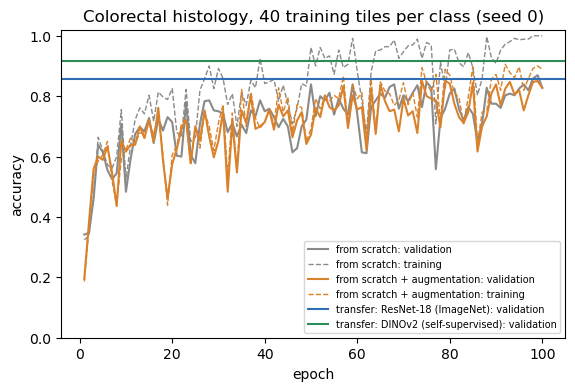

                                     validation   TEST
from scratch                              0.861  0.745   (three seeds: 0.721-0.786)
from scratch + augmentation               0.855  0.792   (three seeds: 0.769-0.821)
transfer: ResNet-18 (ImageNet)            0.856  0.780
transfer: DINOv2 (self-supervised)        0.917  0.832


In [10]:
plt.figure(figsize=(6.5, 4))
for name, color in [("from scratch", "#8a8a8a"), ("from scratch + augmentation", "#d9822b")]:
    tr, va = zip(*results[name]["runs"][0]["hist"])
    plt.plot(np.arange(1, len(va) + 1), va, color=color, label=f"{name}: validation")
    plt.plot(np.arange(1, len(tr) + 1), tr, color=color, ls="--", lw=1, label=f"{name}: training")
for name, color in [("transfer: ResNet-18 (ImageNet)", "#2f6db5"), ("transfer: DINOv2 (self-supervised)", "#2e8b57")]:
    plt.axhline(results[name]["val"], color=color, label=f"{name}: validation")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.ylim(0, 1.02)
plt.title("Colorectal histology, 40 training tiles per class (seed 0)")
plt.legend(fontsize=7, loc="lower right")
plt.savefig(f"{FIGS}/session10-crc-curves.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"{'':36s} {'validation':>10s} {'TEST':>6s}")
for name, r in results.items():
    extra = f"   (three seeds: {r['test_range'][0]:.3f}-{r['test_range'][1]:.3f})" if "test_range" in r else ""
    print(f"{name:36s} {r['val']:10.3f} {r['test']:6.3f}{extra}")

### Validation from the same slides, test from new patients

Every model scores clearly higher on the validation tiles than on the
test tiles. The validation tiles can come from the same slides, and so
the same patients, staining runs and scanner settings, as the training
tiles; the test tiles come from 50 patients the model has never seen.
This is Session 8's homology trap again, now for images: whenever
examples come in related groups (proteins in families, tiles in
patients), the honest split is by group. Which tissue types does the best
model confuse on the new patients?

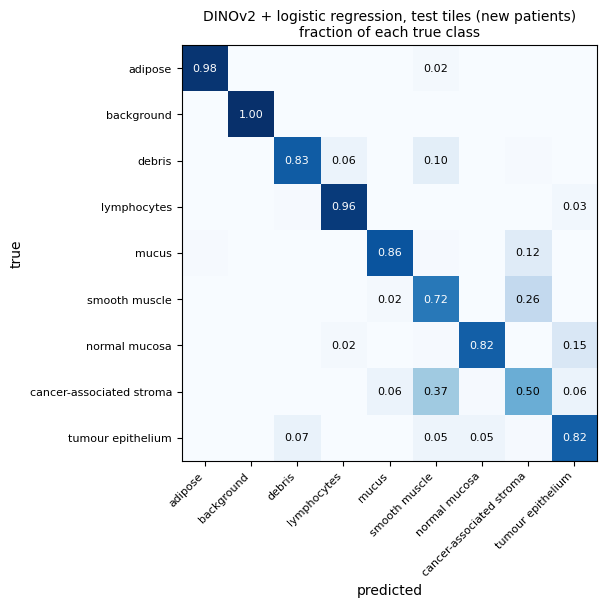

cancer-associated stroma   correct 0.50; most often mistaken for smooth muscle (0.37)
smooth muscle              correct 0.72; most often mistaken for cancer-associated stroma (0.26)
normal mucosa              correct 0.82; most often mistaken for tumour epithelium (0.15)


In [11]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(tiles["test"][1], dino_test_pred, normalize="true")
fig, ax = plt.subplots(figsize=(6.2, 5.4))
ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
for i in range(9):
    for j in range(9):
        if cm[i, j] >= 0.02:
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=8, color="white" if cm[i, j] > 0.5 else "black")
ax.set_xticks(range(9)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(9)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("DINOv2 + logistic regression, test tiles (new patients)\nfraction of each true class", fontsize=10)
plt.savefig(f"{FIGS}/session10-crc-confusion.png", dpi=150, bbox_inches="tight"); plt.show()
for i in np.argsort(np.diag(cm))[:3]:
    j = int(np.argmax(np.where(np.arange(9) == i, -1, cm[i])))
    print(f"{CLASS_NAMES[i]:26s} correct {cm[i, i]:.2f}; most often mistaken for {CLASS_NAMES[j]} ({cm[i, j]:.2f})")

## What a CNN is (and isn't) invariant to

Convolution plus pooling makes a CNN largely insensitive to *where* a
pattern is. Nothing in the architecture makes it insensitive to
*rotation* or mirroring. Accuracy alone can hide this, so we ask a
sharper question: **for what fraction of the test tiles does the predicted
class change** when the same tile is shifted, rotated or mirrored? A
truly invariant classifier would change none. For a fair comparison every
version is a 96 × 96 pixel crop: the centre crop, the crop shifted by 8
pixels, or the centre crop rotated or mirrored (rotations by multiples of
90° and mirror images lose no pixels).

CNN from scratch     accuracy on centre crops 0.771;  predictions changed: shift 8 px 0.051  rotate 90° 0.182  rotate 180° 0.077  mirror 0.167


CNN + augmentation   accuracy on centre crops 0.754;  predictions changed: shift 8 px 0.057  rotate 90° 0.091  rotate 180° 0.032  mirror 0.074


ResNet-18 transfer   accuracy on centre crops 0.783;  predictions changed: shift 8 px 0.118  rotate 90° 0.176  rotate 180° 0.143  mirror 0.103


DINOv2 transfer      accuracy on centre crops 0.809;  predictions changed: shift 8 px 0.097  rotate 90° 0.118  rotate 180° 0.076  mirror 0.063


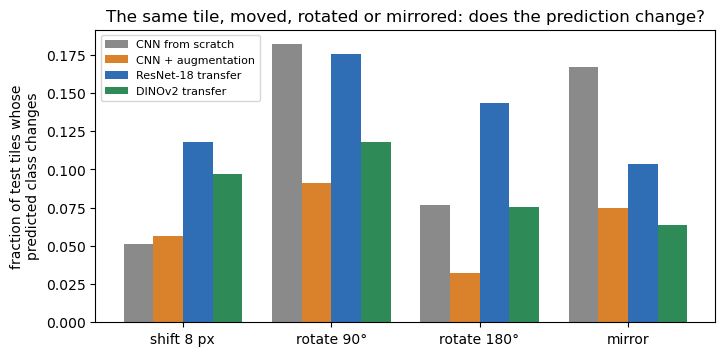

In [12]:
def view(k=0, mirror=False, shift=0, crop=96):
    def f(img):
        w = img.size[0]; a = (w - crop) // 2 + shift
        img = img.crop((a, a, a + crop, a + crop)).rotate(90 * k)
        return img.transpose(Image.FLIP_LEFT_RIGHT) if mirror else img
    return f

tests = {"shift 8 px": view(shift=8), "rotate 90°": view(k=1), "rotate 180°": view(k=2), "mirror": view(mirror=True)}
classifiers = {
    "CNN from scratch": lambda v: predict(models["from scratch"], cache(Tiles("test", T.Compose([v, T.ToTensor(), norm])))),
    "CNN + augmentation": lambda v: predict(models["from scratch + augmentation"], cache(Tiles("test", T.Compose([v, T.ToTensor(), norm])))),
    "ResNet-18 transfer": lambda v: heads["transfer: ResNet-18 (ImageNet)"].predict(
        features(backbones["transfer: ResNet-18 (ImageNet)"], "test", T.Compose([v, T.Resize(224), T.ToTensor(), norm]))),
    "DINOv2 transfer": lambda v: heads["transfer: DINOv2 (self-supervised)"].predict(
        features(backbones["transfer: DINOv2 (self-supervised)"], "test", T.Compose([v, T.Resize(224), T.ToTensor(), norm]))),
}
changed = {}
for cname, clf in classifiers.items():
    base = clf(view())
    changed[cname] = {t: (clf(v) != base).mean() for t, v in tests.items()}
    print(f"{cname:20s} accuracy on centre crops {(base == tiles['test'][1]).mean():.3f};  predictions changed: "
          + "  ".join(f"{t} {c:.3f}" for t, c in changed[cname].items()))

fig, ax = plt.subplots(figsize=(8, 3.8))
width = 0.2
for i, (cname, color) in enumerate(zip(classifiers, ["#8a8a8a", "#d9822b", "#2f6db5", "#2e8b57"])):
    vals = [changed[cname][t] for t in tests]
    ax.bar(np.arange(len(tests)) + (i - 1.5) * width, vals, width, color=color, label=cname)
ax.set_xticks(range(len(tests))); ax.set_xticklabels(list(tests))
ax.set_ylabel("fraction of test tiles whose\npredicted class changes")
ax.set_title("The same tile, moved, rotated or mirrored: does the prediction change?")
ax.legend(fontsize=8)
plt.savefig(f"{FIGS}/session10-rotation-shift.png", dpi=150, bbox_inches="tight"); plt.show()

Without augmentation, rotating a tile by 90° changes the CNN's predicted
class for about one test tile in five, and mirroring it almost as often,
although nothing about the tissue has changed. Shifting the window by 8
pixels changes far fewer: convolution and pooling take care of
*position*, not of *orientation*. Training on rotated and mirrored copies
roughly halves the changes. The network learned the symmetry from the
data, because the architecture could not give it.

The pretrained networks are not invariant either. ImageNet photos are
almost always upright, so ResNet-18 never needed to ignore rotations.
DINOv2 saw mirrored images during its self-supervised training, but no
rotated ones, and it shows: mirroring changes fewer of its predictions
than a 90° rotation does. This is why histology pipelines augment with
all rotations and flips, and why rotation-equivariant CNNs, which build
the symmetry into the architecture, were developed for pathology (Veeling
et al. 2018).

# Part 2 — CNNs on protein sequences

## Part 2: the subcellular-localization case study, this time with a 1D CNN

Same dataset, same encoding, same homology-aware train/val/test split as Sessions 8-9 (fetched
live from UniProt again here, with the same fixed random seeds, so it should
reproduce the same 700-protein, 5-class, 486/105/109 homology-aware split) -- but this time
the classifier is a 1D convolutional network over the sequence, instead of a
flat fully-connected one, directly demonstrating the "1D convolution over a
sequence" idea from the book page.

In [13]:
import re
import requests

UNIPROT_CLASSES = {
    "Cytoplasm": "SL-0086",
    "Nucleus": "SL-0191",
    "Mitochondrion": "SL-0173",
    "Secreted": "SL-0243",
    "Cell membrane": "SL-0039",
}
CLASS_NAMES = list(UNIPROT_CLASSES.keys())

def fetch_uniprot(sl_code, size=500):
    query = f"organism_id:9606 AND reviewed:true AND cc_scl_term:{sl_code} AND length:[50 TO 500]"
    r = requests.get(
        "https://rest.uniprot.org/uniprotkb/search",
        params={"query": query, "fields": "accession,sequence,cc_subcellular_location",
                "format": "tsv", "size": size},
        timeout=60,
    )
    r.raise_for_status()
    rows = []
    for line in r.text.strip().split("\n")[1:]:
        parts = line.split("\t")
        if len(parts) == 3:
            rows.append(tuple(parts))
    return rows

def is_unambiguous_single_location(location_text, target):
    location_text = re.sub(r"Note=.*", "", location_text)
    location_text = re.sub(r"\{[^}]*\}", "", location_text)
    if "Isoform" in location_text:
        return False
    terms = set()
    for statement in [s.strip() for s in location_text.split(".") if s.strip()]:
        body = statement.split(":", 1)[-1] if ":" in statement else statement
        top_term = re.split(r"[,;]", body)[0].strip().rstrip(".")
        if top_term:
            terms.add(top_term)
    return terms == {target}

entries_by_class = {name: [] for name in CLASS_NAMES}
for name, code in UNIPROT_CLASSES.items():
    rows = fetch_uniprot(code, size=500)
    kept = [(acc, seq) for (acc, seq, loc) in rows if is_unambiguous_single_location(loc, name)]
    entries_by_class[name] = kept
    print(f"{name}: fetched {len(rows)}, unambiguous single-location {len(kept)}")

Cytoplasm: fetched 500, unambiguous single-location 424


Nucleus: fetched 500, unambiguous single-location 497


Mitochondrion: fetched 500, unambiguous single-location 140


Secreted: fetched 500, unambiguous single-location 488


Cell membrane: fetched 500, unambiguous single-location 338


In [14]:
N_PER_CLASS = min(len(v) for v in entries_by_class.values())
print("balancing every class to", N_PER_CLASS, "sequences")

rng = np.random.RandomState(0)
balanced_accs, balanced_seqs, balanced_labels = [], [], []
for class_idx, class_name in enumerate(CLASS_NAMES):
    pool = entries_by_class[class_name]
    for i in rng.choice(len(pool), N_PER_CLASS, replace=False):
        balanced_accs.append(pool[i][0])
        balanced_seqs.append(pool[i][1])
        balanced_labels.append(class_idx)

print("total balanced dataset:", len(balanced_seqs), "sequences,", len(CLASS_NAMES), "classes")
print("(Session 8/9 reported 700 sequences, 140/class -- checking this matches)")

balancing every class to 140 sequences
total balanced dataset: 700 sequences, 5 classes
(Session 8/9 reported 700 sequences, 140/class -- checking this matches)


In [15]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
SEQ_LEN = 150

def one_hot_encode(sequence, length=SEQ_LEN):
    encoded = np.zeros((length, len(AMINO_ACIDS)), dtype=np.float32)
    for position, residue in enumerate(sequence[:length]):
        if residue in AA_TO_INDEX:
            encoded[position, AA_TO_INDEX[residue]] = 1.0
    return encoded  # (SEQ_LEN, 20) -- NOT flattened this time, a CNN wants the 2D shape

X = np.stack([one_hot_encode(s) for s in balanced_seqs])       # (N, 150, 20)
X = X.transpose(0, 2, 1)                                        # (N, 20, 150): channels=amino acids, length=position
y = np.array(balanced_labels)
print("X shape:", X.shape, " (N, channels=20 amino acids, length=150 positions)")
print("y shape:", y.shape)

X shape: (700, 20, 150)  (N, channels=20 amino acids, length=150 positions)
y shape: (700,)


In [16]:
import os, shutil, subprocess, tempfile

# Session 8's homology-aware split: MMseqs2 clusters at 30% identity, whole clusters per split
CLUSTER_URL = "https://raw.githubusercontent.com/ElofssonLab/kb8029-book/main/notebooks/data/session08-subcell-mmseqs-30.tsv"
LOCAL_TSV = "data/session08-subcell-mmseqs-30.tsv"

def mmseqs_clusters(accs, seqs, min_seq_id=0.3):
    tmp = tempfile.mkdtemp()
    with open(f"{tmp}/in.fasta", "w") as f:
        for a, s in zip(accs, seqs):
            f.write(f">{a}\n{s}\n")
    subprocess.run(["mmseqs", "easy-cluster", f"{tmp}/in.fasta", f"{tmp}/clu", f"{tmp}/work",
                    "--min-seq-id", str(min_seq_id), "-c", "0.5", "-v", "1"],
                   check=True, stdout=subprocess.DEVNULL)
    pairs = [line.split("\t") for line in open(f"{tmp}/clu_cluster.tsv").read().split("\n") if line]
    shutil.rmtree(tmp)
    return {member: rep for rep, member in pairs}

def load_precomputed_clusters():
    text = open(LOCAL_TSV).read() if os.path.exists(LOCAL_TSV) else requests.get(CLUSTER_URL, timeout=30).text
    pairs = [line.split("\t") for line in text.strip().split("\n")[1:]]
    return {member: rep for rep, member in pairs}

if shutil.which("mmseqs"):
    member_to_rep = mmseqs_clusters(balanced_accs, balanced_seqs)
    print("clustered with local MMseqs2 (30% identity, 50% coverage)")
else:
    member_to_rep = load_precomputed_clusters()
    print("mmseqs not found -- loaded the precomputed MMseqs2 clustering")

# proteins missing from the clustering (e.g. if UniProt changed) become their own cluster
reps = [member_to_rep.get(a, a) for a in balanced_accs]
rep_ids = {r: i for i, r in enumerate(sorted(set(reps)))}
groups = np.array([rep_ids[r] for r in reps])
sizes = np.bincount(groups)
print(f"{len(y)} proteins -> {len(sizes)} clusters; "
      f"{(sizes > 1).sum()} clusters have more than one member ({sizes[sizes > 1].sum()} proteins), largest has {sizes.max()}")

def homology_split(y, groups, fractions=(0.70, 0.15, 0.15), seed=0):
    '''Assign whole clusters, in random order, to train/val/test: each cluster
    goes to the split furthest below its target share of that cluster's
    classes (ties broken at random). Returns three index arrays.'''
    rng = np.random.RandomState(seed)
    n_classes = y.max() + 1
    target = np.outer(fractions, np.bincount(y, minlength=n_classes))   # (3 splits, n_classes)
    have = np.zeros_like(target)
    assignment = {}
    for g in rng.permutation(np.unique(groups)):
        cls_counts = np.bincount(y[groups == g], minlength=n_classes)
        deficit = ((target - have) * (cls_counts > 0)).sum(axis=1) / target.sum(axis=1)
        best = np.flatnonzero(deficit == deficit.max())
        split = int(rng.choice(best))
        assignment[g] = split
        have[split] += cls_counts
    split_of = np.array([assignment[g] for g in groups])
    return [np.where(split_of == k)[0] for k in range(3)]

tr_h, va_h, te_h = homology_split(y, groups)
X_train, y_train = X[tr_h], y[tr_h]
X_val, y_val = X[va_h], y[va_h]
X_test, y_test = X[te_h], y[te_h]
print(f"train: {len(X_train)}   val: {len(X_val)}   test: {len(X_test)}")
print("(Session 8/9 reported 486 / 105 / 109 -- checking this matches)")

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

clustered with local MMseqs2 (30% identity, 50% coverage)
700 proteins -> 551 clusters; 75 clusters have more than one member (224 proteins), largest has 11
train: 486   val: 105   test: 109
(Session 8/9 reported 486 / 105 / 109 -- checking this matches)


### A 1D-CNN classifier

Two convolutional layers (kernel size 7, i.e. each filter looks at a 7-residue
window) with ReLU and max-pooling, then global average pooling over the
remaining sequence length (making the classifier's decision insensitive to
*where* along the sequence a signal was detected -- exactly Part 1's
equivariance-then-pooling argument, now inside a real classifier), then a
linear layer to the 5 classes.

In [17]:
torch.manual_seed(0)   # fixed initial weights, independent of what ran in Part 1
class LocalizationCNN(nn.Module):
    def __init__(self, n_classes=5, n_channels=20):
        super().__init__()
        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=7, padding=3)
        self.pool = nn.MaxPool1d(2)
        self.classifier = nn.Linear(64, n_classes)

    def forward(self, x):                      # x: (batch, 20, 150)
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = torch.adaptive_avg_pool1d(x, 1).squeeze(-1)   # global average pool -> (batch, 64)
        return self.classifier(x)               # raw logits, (batch, n_classes)


cnn_model = LocalizationCNN()
n_params = sum(p.numel() for p in cnn_model.parameters())
print(cnn_model)
print("total trainable parameters:", n_params)
print("(Session 8/9's flat MLP had ~192,389 parameters -- for comparison)")

LocalizationCNN(
  (conv1): Conv1d(20, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (classifier): Linear(in_features=64, out_features=5, bias=True)
)
total trainable parameters: 19237
(Session 8/9's flat MLP had ~192,389 parameters -- for comparison)


In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)

best_val_acc = 0.0
best_state = None
history = {"train_acc": [], "val_acc": []}

def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1)
    return (preds == y).float().mean().item()

for epoch in range(100):
    cnn_model.train()
    optimizer.zero_grad()
    logits = cnn_model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()

    train_acc = accuracy(cnn_model, X_train_t, y_train_t)
    val_acc = accuracy(cnn_model, X_val_t, y_val_t)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_state = {k: v.clone() for k, v in cnn_model.state_dict().items()}

cnn_model.load_state_dict(best_state)
print(f"best validation accuracy {best_val_acc:.3f} at epoch {best_epoch} of 100 (early-stopped, same practice as Session 9)")
print(f"final train accuracy at that epoch: {history['train_acc'][best_epoch]:.3f}")

best validation accuracy 0.619 at epoch 72 of 100 (early-stopped, same practice as Session 9)
final train accuracy at that epoch: 0.667


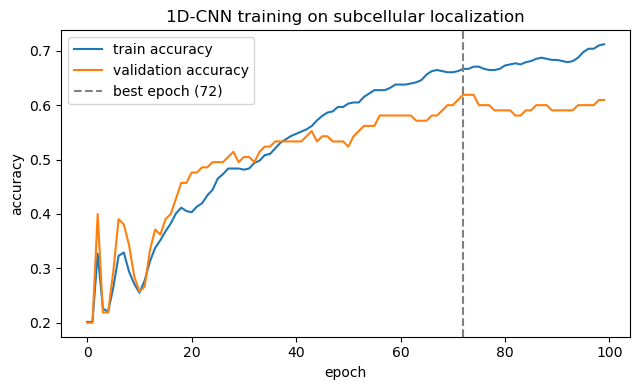

In [19]:
plt.figure(figsize=(6.5, 4))
plt.plot(history["train_acc"], label="train accuracy")
plt.plot(history["val_acc"], label="validation accuracy")
plt.axvline(best_epoch, linestyle="--", color="gray", label=f"best epoch ({best_epoch})")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("1D-CNN training on subcellular localization")
plt.legend()
plt.tight_layout()
plt.savefig("../figs/session10-cnn-training-curve.png", dpi=150)
plt.show()

### Evaluating on the held-out test set, with the same metrics as Session 8/9

In [20]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, matthews_corrcoef
import torch.nn.functional as F

cnn_model.eval()
with torch.no_grad():
    test_logits = cnn_model(X_test_t)
    test_probs = F.softmax(test_logits, dim=1).numpy()
    test_preds = test_logits.argmax(dim=1).numpy()

cnn_test_acc = (test_preds == y_test).mean()
precision, recall, f1, _ = precision_recall_fscore_support(y_test, test_preds, average="macro", zero_division=0)
cnn_mcc = matthews_corrcoef(y_test, test_preds)
cnn_auroc = roc_auc_score(y_test, test_probs, multi_class="ovr", average="macro")

print(f"1D-CNN  test accuracy:  {cnn_test_acc:.3f}")
print(f"1D-CNN  macro F1:       {f1:.3f}")
print(f"1D-CNN  MCC:            {cnn_mcc:.3f}")
print(f"1D-CNN  macro AUROC:    {cnn_auroc:.3f}")
print()
print("For comparison, on the SAME homology-aware test set (Sessions 8-9):")
print("  flat MLP, untrained (Session 8, validation set): accuracy 0.181, macro F1 0.124, MCC -0.027, macro AUROC 0.474")
print("  flat MLP, trained, early-stopped (Session 9):    accuracy 0.514, macro F1 0.493, MCC 0.394, macro AUROC 0.831")
print("  logistic regression, no hidden layer (Session 9): accuracy 0.569,                 MCC 0.461, macro AUROC 0.849")

1D-CNN  test accuracy:  0.587
1D-CNN  macro F1:       0.586
1D-CNN  MCC:            0.484
1D-CNN  macro AUROC:    0.869

For comparison, on the SAME homology-aware test set (Sessions 8-9):
  flat MLP, untrained (Session 8, validation set): accuracy 0.181, macro F1 0.124, MCC -0.027, macro AUROC 0.474
  flat MLP, trained, early-stopped (Session 9):    accuracy 0.514, macro F1 0.493, MCC 0.394, macro AUROC 0.831
  logistic regression, no hidden layer (Session 9): accuracy 0.569,                 MCC 0.461, macro AUROC 0.849


## Inside the first layer: filters are learned PWMs

Each first-layer filter is a 20 × 7 matrix of weights: one weight per
amino acid per position in a 7-residue window. That is the shape
of a position weight matrix (Session 5), except that the network learned it
from the class labels instead of from an alignment. Which filters matter
for **secreted** proteins? For every filter, compare its strongest
response along the sequence in secreted vs. all other proteins, then look
at the most selective ones.

In [21]:
from scipy.stats import pearsonr
KD = {'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5, 'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
      'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6, 'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2}
kd = np.array([KD[a] for a in AMINO_ACIDS])

cnn_model.eval()
with torch.no_grad():
    act = torch.relu(cnn_model.conv1(torch.tensor(X, dtype=torch.float32)))   # (proteins, filters, positions)
peak_value = act.max(dim=2).values.numpy()
peak_pos = act.argmax(dim=2).numpy()
is_sec = (y == CLASS_NAMES.index("Secreted"))
selectivity = peak_value[is_sec].mean(0) - peak_value[~is_sec].mean(0)
W1 = cnn_model.conv1.weight.detach().numpy()                                  # (filters, 20 amino acids, 7 positions)

print("the 5 filters most selective for secreted proteins:")
for f in np.argsort(-selectivity)[:5]:
    r, p = pearsonr(W1[f].mean(axis=1), kd)
    print(f"  filter {f:2d}: correlation of its amino-acid weights with Kyte-Doolittle hydrophobicity r = {r:.2f} "
          f"(p = {p:.0e}); peak position median {np.median(peak_pos[is_sec, f]):.0f} in secreted, "
          f"{np.median(peak_pos[~is_sec, f]):.0f} in other proteins")
all_r = [pearsonr(W1[f].mean(axis=1), kd)[0] for f in range(W1.shape[0])]
print(f"for comparison, all {W1.shape[0]} filters: mean r = {np.mean(all_r):.2f}")

the 5 filters most selective for secreted proteins:
  filter  3: correlation of its amino-acid weights with Kyte-Doolittle hydrophobicity r = 0.81 (p = 1e-05); peak position median 12 in secreted, 76 in other proteins
  filter 18: correlation of its amino-acid weights with Kyte-Doolittle hydrophobicity r = 0.70 (p = 6e-04); peak position median 11 in secreted, 62 in other proteins
  filter 21: correlation of its amino-acid weights with Kyte-Doolittle hydrophobicity r = 0.76 (p = 1e-04); peak position median 11 in secreted, 74 in other proteins
  filter 27: correlation of its amino-acid weights with Kyte-Doolittle hydrophobicity r = 0.72 (p = 3e-04); peak position median 12 in secreted, 67 in other proteins
  filter 24: correlation of its amino-acid weights with Kyte-Doolittle hydrophobicity r = 0.83 (p = 6e-06); peak position median 11 in secreted, 74 in other proteins
for comparison, all 32 filters: mean r = 0.12


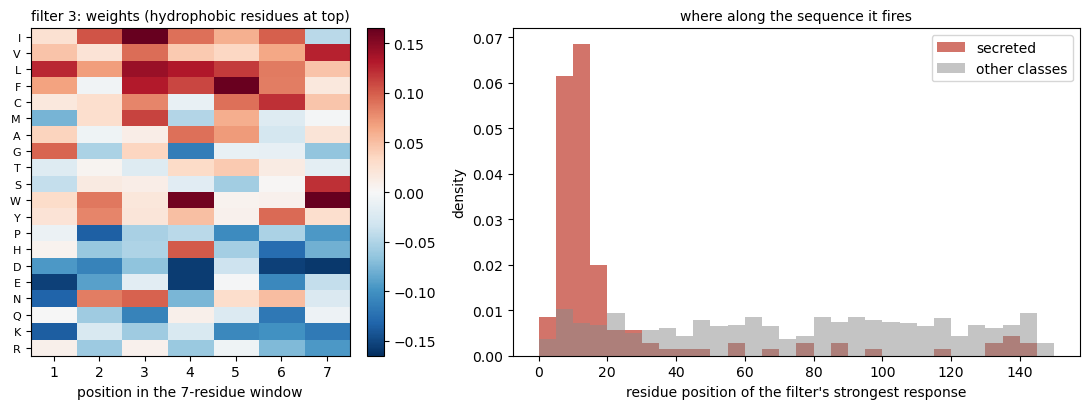

In [22]:
best = int(np.argmax(selectivity))
order = np.argsort(-kd)                                   # most hydrophobic amino acids at the top
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1, 1.6]})
lim = np.abs(W1[best]).max()
im = a1.imshow(W1[best][order], cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
a1.set_yticks(range(20)); a1.set_yticklabels([AMINO_ACIDS[i] for i in order], fontsize=8)
a1.set_xticks(range(7)); a1.set_xticklabels(range(1, 8)); a1.set_xlabel("position in the 7-residue window")
a1.set_title(f"filter {best}: weights (hydrophobic residues at top)", fontsize=10)
plt.colorbar(im, ax=a1, fraction=0.05)
bins = np.arange(0, SEQ_LEN + 1, 5)
a2.hist(peak_pos[is_sec, best], bins=bins, alpha=0.7, color="#c0392b", label="secreted", density=True)
a2.hist(peak_pos[~is_sec, best], bins=bins, alpha=0.5, color="#8a8a8a", label="other classes", density=True)
a2.set_xlabel("residue position of the filter's strongest response"); a2.set_ylabel("density")
a2.set_title("where along the sequence it fires", fontsize=10); a2.legend()
plt.tight_layout(); plt.savefig(f"{FIGS}/session10-signal-filter.png", dpi=150, bbox_inches="tight"); plt.show()

Nobody told the network about signal peptides. It was given one-hot
sequences and five labels. Yet its most secreted-specific filters weight
hydrophobic residues (L, I, V, F...) positively and charged ones
negatively, and they fire around residues 10-15: the hydrophobic core of
a signal peptide (Session 11 returns to signal peptides in detail). DeepBind
(Alipanahi et al., 2015) made the same observation for DNA: the
first-layer filters of CNNs trained on binding data match known
transcription-factor motifs.

# Part 3 — Contact maps: images made from protein structures

A **contact map** marks which residue pairs are close in 3D: here, pairs
whose Cβ atoms (Cα for glycine) are within 8 Å, the standard CASP
definition. Computed from the real crystal structure of hemoglobin
(PDB 4HHB, chain B = β-globin, Session 6), with the helices from the PDB
file's own annotation drawn along the axes:

In [23]:
import io, requests
from Bio.PDB import PDBParser
pdb_text = requests.get("https://files.rcsb.org/download/4HHB.pdb", timeout=60).text
chain = PDBParser(QUIET=True).get_structure("4HHB", io.StringIO(pdb_text))[0]["B"]
residues = [r for r in chain if r.id[0] == " "]
coords = np.array([(r["CB"] if "CB" in r else r["CA"]).coord for r in residues])
dist = np.linalg.norm(coords[:, None] - coords[None], axis=2)
contact = dist < 8.0
L = len(residues)
i, j = np.triu_indices(L, 6)
sep = j - i
print(f"{L} residues; contacts with |i-j| >= 6: {contact[i, j].sum()}, of which long-range (|i-j| >= 24): "
      f"{contact[i, j][sep >= 24].sum()}, medium-range (12-23): {contact[i, j][(sep >= 12) & (sep < 24)].sum()}")
helices = [(int(l[21:25]), int(l[33:37])) for l in pdb_text.splitlines() if l.startswith("HELIX") and l[19] == "B"]
print("helices (residue ranges):", helices)

146 residues; contacts with |i-j| >= 6: 197, of which long-range (|i-j| >= 24): 150, medium-range (12-23): 24
helices (residue ranges): [(4, 18), (19, 34), (35, 41), (50, 56), (57, 76), (85, 93), (99, 117), (123, 143)]


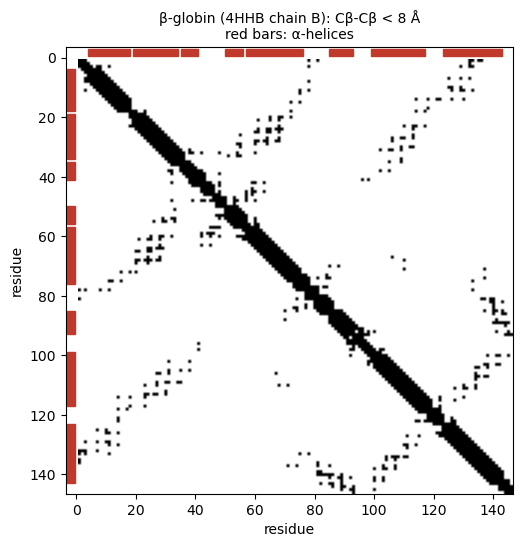

In [24]:
fig, ax = plt.subplots(figsize=(5.8, 5.8))
ax.imshow(contact, cmap="Greys", origin="upper", extent=(0.5, L + 0.5, L + 0.5, 0.5))
for k, (a, b) in enumerate(helices):
    for rect in [plt.Rectangle((a, -3), b - a, 2.5), plt.Rectangle((-3, a), 2.5, b - a)]:
        rect.set_color("#c0392b"); rect.set_clip_on(False); ax.add_patch(rect)
ax.set_xlim(-3.5, L + 0.5); ax.set_ylim(L + 0.5, -3.5)
ax.set_xlabel("residue"); ax.set_ylabel("residue")
ax.set_title("β-globin (4HHB chain B): Cβ-Cβ < 8 Å\nred bars: α-helices", fontsize=10)
plt.savefig(f"{FIGS}/session10-hbb-contact-map.png", dpi=150, bbox_inches="tight"); plt.show()

The thick band along the diagonal is each helix contacting itself. The
off-diagonal blocks are helix packing against helix. Those long-range
contacts carry the information about the fold, and they are what
contact-prediction methods try to predict from sequence alone. To a CNN,
a contact map is just an L × L image. Predicting it from pairwise features
of a multiple sequence alignment is the image-to-image problem that deep
residual CNNs cracked around 2016-2018 (book page, Part 3), leading
directly to AlphaFold (Session 12).

## Try it yourself

- In Part 1, change `EPOCHS` or the augmentation (e.g. remove `RandomRotation`)
  and re-run. How much of the augmentation gain survives?
- In Part 2, print the weights of the filter most selective for
  **mitochondrion** instead. Mitochondrial targeting peptides are
  amphipathic and rich in arginine: do you see that?
- In Part 3, use an 8 Å cutoff on Cα atoms instead of Cβ. How many
  long-range contacts do you gain or lose?